In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score,precision_recall_curve,precision_score,recall_score,f1_score
# import tensorflow_hub as hub

In [3]:
#load the dataset
df=pd.read_csv("spam.csv",encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [5]:
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1,inplace=True)

In [6]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [7]:
df.rename(columns={"v1":"target","v2":"text"},inplace=True)

In [8]:
df.columns

Index(['target', 'text'], dtype='object')

In [9]:
df["label_en"]=df.target.map({"ham":0,"spam":1})
df.head()

,target,text,label_en
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [10]:
x_train,x_test,y_train,y_test=train_test_split(df["text"],df["label_en"],test_size=0.2,random_state=42)

In [12]:
x_train,x_train.shape

(1978    Reply to win ÃÂ£100 weekly! Where will the 20...
 3989    Hello. Sort of out in town already. That . So ...
 3935     How come guoyang go n tell her? Then u told her?
 4078    Hey sathya till now we dint meet not even a si...
 4086    Orange brings you ringtones from all time Char...
                               ...                        
 3772    Hi, wlcome back, did wonder if you got eaten b...
 5191                               Sorry, I'll call later
 5226        Prabha..i'm soryda..realy..frm heart i'm sory
 5390                           Nt joking seriously i told
 860               Did he just say somebody is named tampa
 Name: text, Length: 4457, dtype: object,
 (4457,))

In [13]:
x_train_np=x_train.to_numpy()
y_train_np=y_train.to_numpy()
x_test_np=x_test.to_numpy()
y_test_np=y_test.to_numpy()

In [16]:
x_train_np,x_train_np.shape

(array(['Reply to win Ã\x82Â£100 weekly! Where will the 2006 FIFA World Cup be held? Send STOP to 87239 to end service',
        'Hello. Sort of out in town already. That . So dont rush home, I am eating nachos. Will let you know eta.',
        'How come guoyang go n tell her? Then u told her?', ...,
        "Prabha..i'm soryda..realy..frm heart i'm sory",
        'Nt joking seriously i told',
        'Did he just say somebody is named tampa'],
       shape=(4457,), dtype=object),
 (4457,))

In [17]:
avg_word_len=round(sum([len(i.split()) for i in df["text"]])/len(df["text"]))
avg_word_len

16

In [19]:
total_word_length=len(set(" ".join(df["text"]).split()))

In [20]:
total_word_length

15686

In [21]:
print(f"Data Loaded. Training samples: {len(x_train_np)}")
print(f"Average words per message: {avg_word_len}")
print(f"Approximate vocabulary size: {total_word_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


In [23]:
def compile_fit(model,epochs=5):
    model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
    
    history=model.fit(x_train_np,y_train_np,epochs=epochs,validation_data=(x_test_np,y_test_np))
    
    return history

In [24]:
def get_metrics(model,x,y):
    y_pred=np.round(model.predict(x))
    
    return {"Accurcay":accuracy_score(y,y_pred),
            "f1":f1_score(y,y_pred),
            "Precision":precision_score(y,y_pred),
            "recall":recall_score(y,y_pred)}
    

In [25]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_word_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_word_len
)
text_vec.adapt(x_train_np)

In [26]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_word_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9069 - loss: 0.2725 - val_accuracy: 0.9614 - val_loss: 0.1394
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 252ms/step - accuracy: 0.9794 - loss: 0.0838 - val_accuracy: 0.9740 - val_loss: 0.0745
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9890 - loss: 0.0391 - val_accuracy: 0.9767 - val_loss: 0.0658
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9937 - loss: 0.0243 - val_accuracy: 0.9785 - val_loss: 0.0741
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9964 - loss: 0.0166 - val_accuracy: 0.9794 - val_loss: 0.0625


In [28]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_word_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 222ms/step - accuracy: 0.9462 - loss: 0.1608 - val_accuracy: 0.9740 - val_loss: 0.0760
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9904 - loss: 0.0374 - val_accuracy: 0.9794 - val_loss: 0.1029
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9964 - loss: 0.0151 - val_accuracy: 0.9812 - val_loss: 0.0871
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.9973 - loss: 0.0070 - val_accuracy: 0.9749 - val_loss: 0.1016
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.9991 - loss: 0.0049 - val_accuracy: 0.9812 - val_loss: 0.0869


In [29]:
results = {
    'Dense Embedding': get_metrics(model_1, x_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, x_test_np, y_test_np)}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
Performance Table:
                 Accurcay        f1  Precision    recall
Dense Embedding  0.979372  0.918728   0.970149  0.872483
Bi-LSTM          0.981166  0.927835   0.950704  0.906040


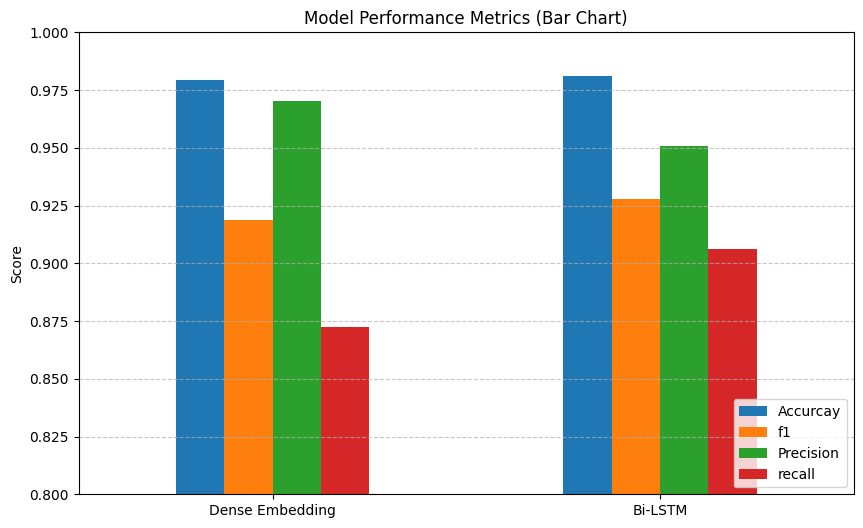

In [30]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

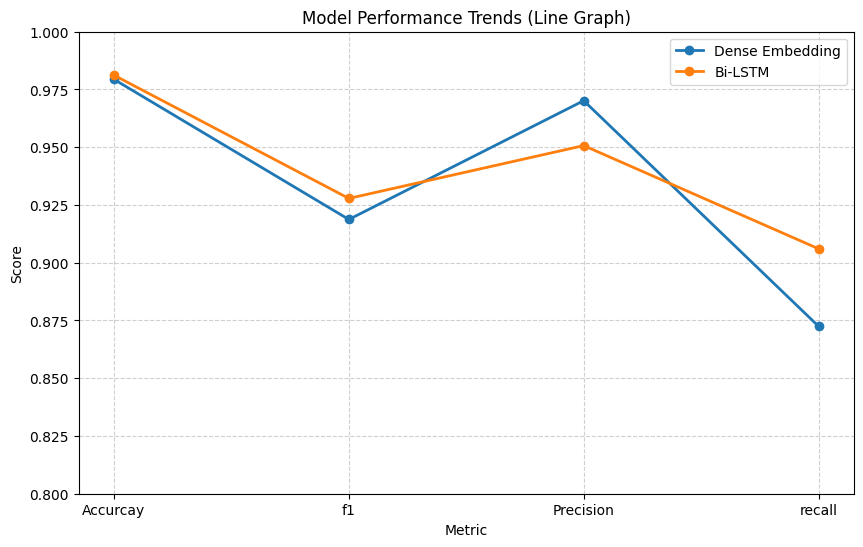

In [31]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()